In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [61]:
crash_roads_data = pd.read_csv('crash_data_roads.csv')
crash_parties_background_data = pd.read_csv('crash_parties_background_info.csv')
crash_parties_car_data = pd.read_csv('crash_parties_car_data.csv')
crash_parties_speed_limit_data = pd.read_csv('crash_parties_speed_limit_data.csv')
crash_data_freeway = pd.read_csv('freeway_crashes.csv') #This and local might be redundant
crash_data_local = pd.read_csv('local_crashes.csv')
crash_data_collision_factors = pd.read_csv('main_collision_factors.csv')

In [56]:
crash_roads_data.head()

,CollisionId,PrimaryRoad,IsFreeway,IsHighwayRelated
0,4550265,SR-79 N/B,False,True
1,4550264,N EL CAMINO REAL,False,False
2,4550263,SR-170 S/B FROM SHERMAN WAY,True,True
3,4550262,SR-126 E/B,True,True
4,4550261,SR-46 W/B,False,False


In [57]:
crash_parties_background_data.head()

,CollisionId,PartyType,Special Information,IsAtFault
0,4541902,Driver,CELL PHONE USE UNKNOWN,True
1,4541901,Driver,CELL PHONE NOT IN USE,False
2,4541901,Driver,CELL PHONE USE UNKNOWN,True
3,4541900,Driver,CELL PHONE NOT IN USE,False
4,4541900,Driver,CELL PHONE NOT IN USE,False


In [58]:
crash_parties_car_data.head()

,CollisionId,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed
0,4541901,2005.0,FORD,F-150,Gray,True
1,4541901,2002.0,FORD,TAURUS,GLD,True
2,4541900,2001.0,SATURN,ION,GLD,False
3,4541900,2020.0,KIA,OPTIMA,White,False
4,4541899,2019.0,TOYOTA,4-RUNNER,Blue,False


In [62]:
crash_parties_speed_limit_data.head()

,CollisionId,SpeedLimit
0,4541902,25.0
1,4541901,40.0
2,4541901,40.0
3,4541900,55.0
4,4541900,55.0


In [60]:
crash_data_collision_factors.head()

,CollisionId,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,NumberKilled,Primary Collision Factor Code,Primary Collision Factor Violation,PrimaryCollisionFactorIsCited,PrimaryCollisionPartyNumber,parsed_values
0,4550265,True,NON-COLLISION,1.0,0.0,A,VC 22107,False,1.0,22107.0
1,4550264,False,OTHER MOTOR VEHICLE,1.0,0.0,A,22350 VC,False,1.0,22350.0
2,4550263,False,OTHER MOTOR VEHICLE,0.0,0.0,A,VC 22107,False,1.0,22107.0
3,4550262,False,OTHER OBJECT,0.0,0.0,A,VC 22350,False,1.0,22350.0
4,4550261,True,OTHER MOTOR VEHICLE,3.0,0.0,A,VC 22450(a),False,1.0,22450.0


Basic Graphics

<Axes: xlabel='Vehicle1Year', ylabel='Count'>

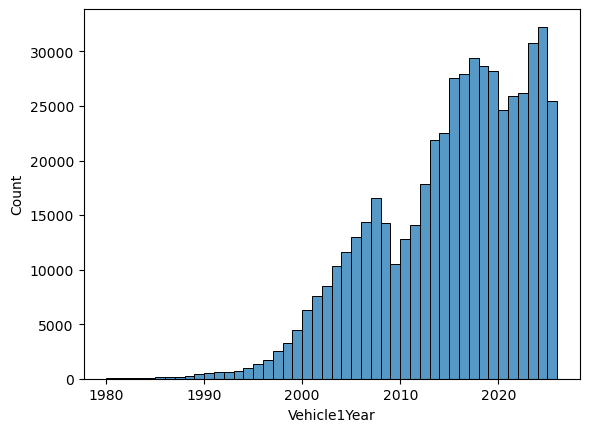

In [8]:
sns.histplot(data=crash_parties_car_data, x='Vehicle1Year', bins=46)

<Axes: xlabel='parsed_values', ylabel='count'>

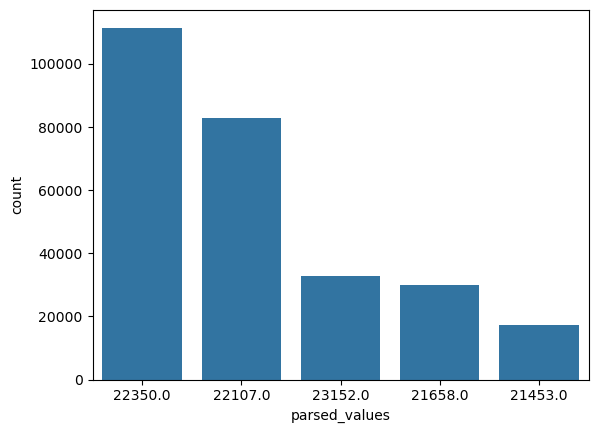

In [9]:
sns.countplot(data = crash_data_collision_factors.sort_values('parsed_values', ascending=False), x = 'parsed_values', order=crash_data_collision_factors['parsed_values'].value_counts().iloc[:5].index)

<Axes: xlabel='Vehicle1Model', ylabel='count'>

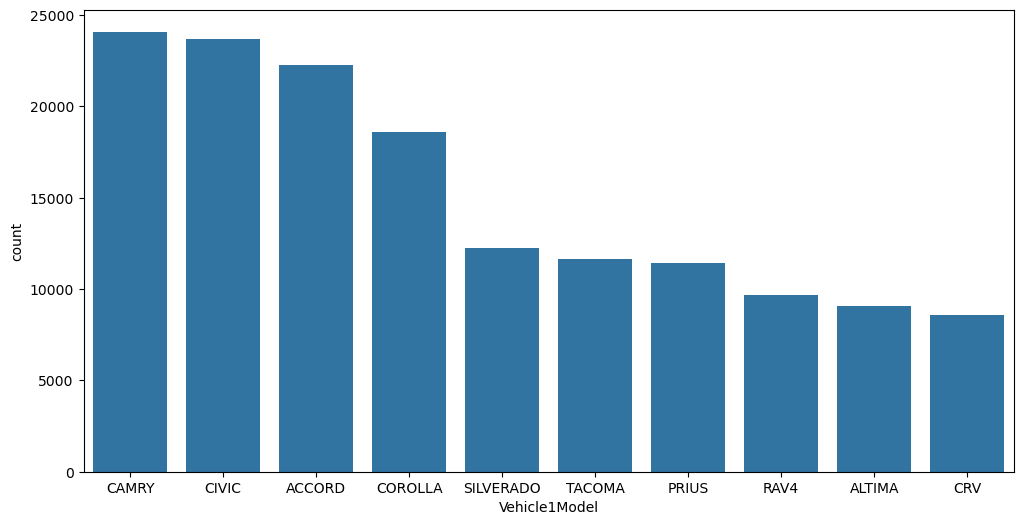

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(data=crash_parties_car_data.sort_values('Vehicle1Model', ascending=False), x='Vehicle1Model', order=crash_parties_car_data['Vehicle1Model'].value_counts().iloc[:10].index, native_scale=True, )

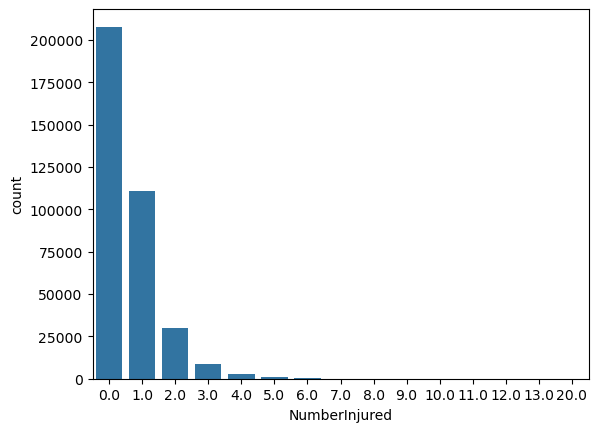

In [11]:
injury = sns.countplot(data = crash_data_collision_factors, x = 'NumberInjured')


<Axes: xlabel='NumberKilled', ylabel='count'>

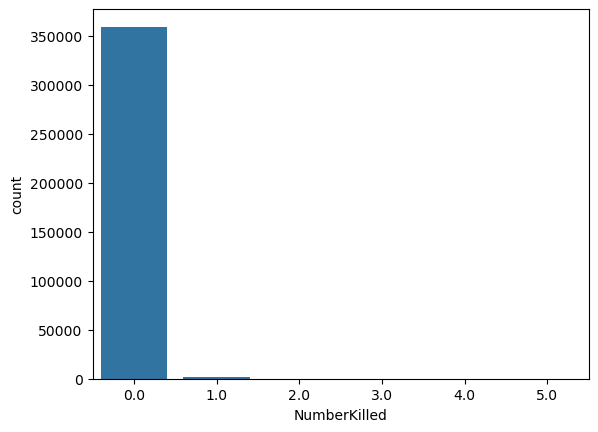

In [12]:
sns.countplot(data=crash_data_collision_factors, x='NumberKilled')

<Axes: ylabel='NumberInjured'>

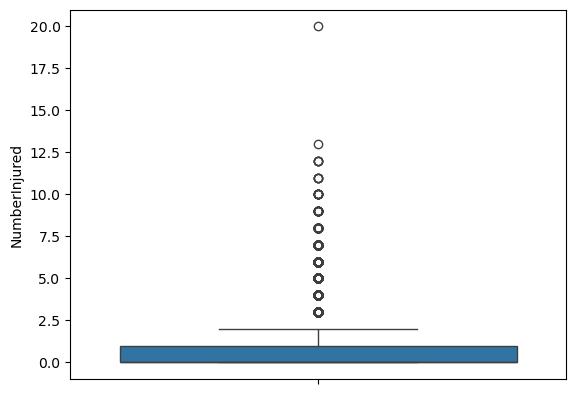

In [13]:
sns.boxplot(data=crash_data_collision_factors, y='NumberInjured')

<Axes: ylabel='NumberKilled'>

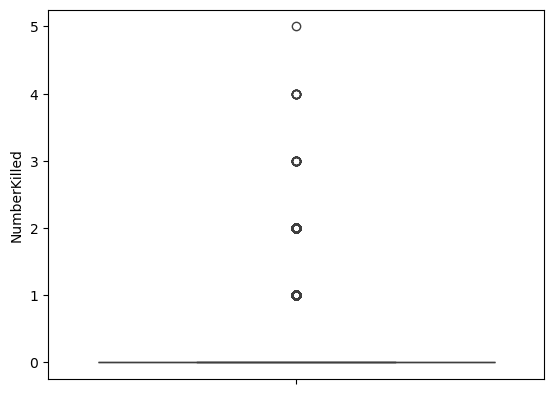

In [14]:
sns.boxplot(data=crash_data_collision_factors, y='NumberKilled')

<Axes: xlabel='Vehicle1Color', ylabel='count'>

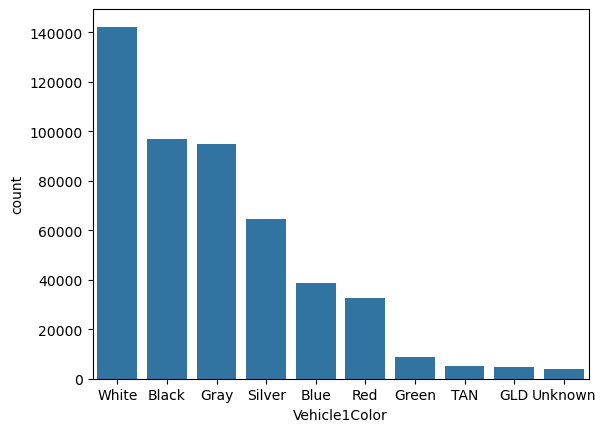

In [15]:
sns.countplot(data = crash_parties_car_data, x = 'Vehicle1Color',  order=crash_parties_car_data['Vehicle1Color'].value_counts().iloc[:10].index)

<Axes: xlabel='SpeedLimit', ylabel='count'>

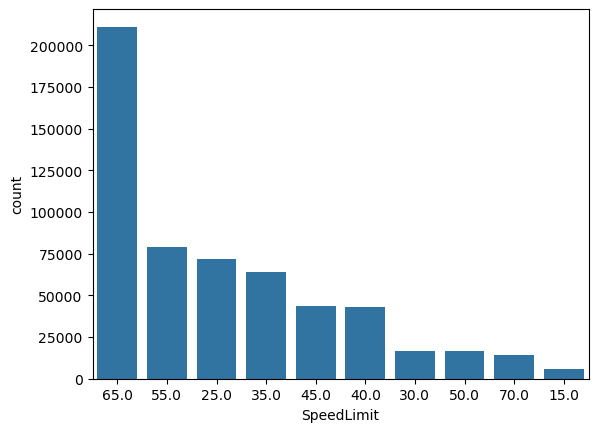

In [16]:
sns.countplot(data = crash_parties_speed_limit_data, x = 'SpeedLimit',  order=crash_parties_speed_limit_data['SpeedLimit'].value_counts().iloc[:10].index)

Joined Graphics

In [17]:
crash_parties_car_data 
crash_parties_background_data

crash_parties_car_background_data = pd.merge(crash_parties_car_data, crash_parties_background_data, on='CollisionId', how='inner')

In [18]:
crash_parties_car_background_data.head()

,Unnamed: 0_x,CollisionId,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,Unnamed: 0_y,PartyType,Special Information,IsAtFault
0,1,4541901,2005.0,FORD,F-150,Gray,True,1,Driver,CELL PHONE NOT IN USE,False
1,1,4541901,2005.0,FORD,F-150,Gray,True,2,Driver,CELL PHONE USE UNKNOWN,True
2,2,4541901,2002.0,FORD,TAURUS,GLD,True,1,Driver,CELL PHONE NOT IN USE,False
3,2,4541901,2002.0,FORD,TAURUS,GLD,True,2,Driver,CELL PHONE USE UNKNOWN,True
4,3,4541900,2001.0,SATURN,ION,GLD,False,3,Driver,CELL PHONE NOT IN USE,False


<Axes: xlabel='Vehicle1Model', ylabel='count'>

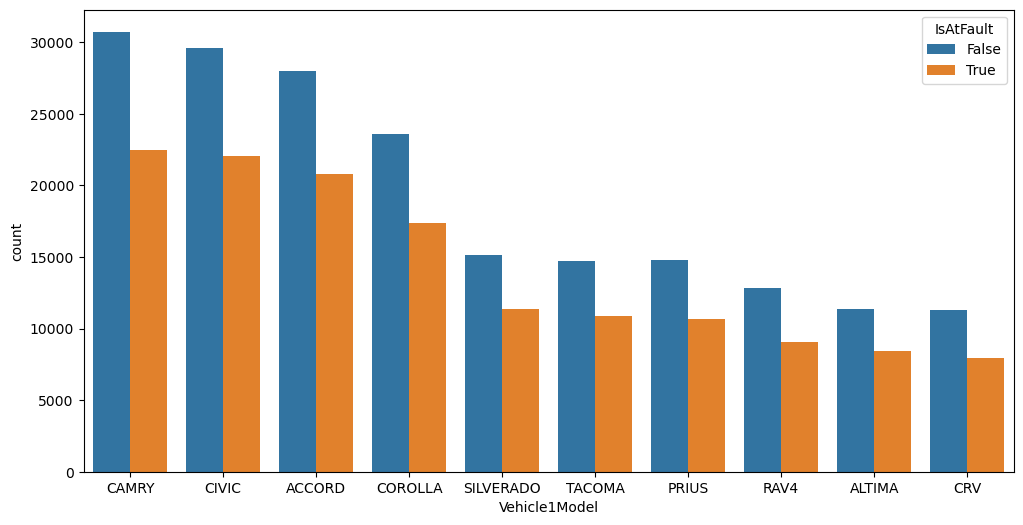

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(data=crash_parties_car_background_data, x='Vehicle1Model', hue = 'IsAtFault', order=crash_parties_car_background_data['Vehicle1Model'].value_counts().iloc[:10].index)

<Axes: xlabel='Vehicle1Year', ylabel='count'>

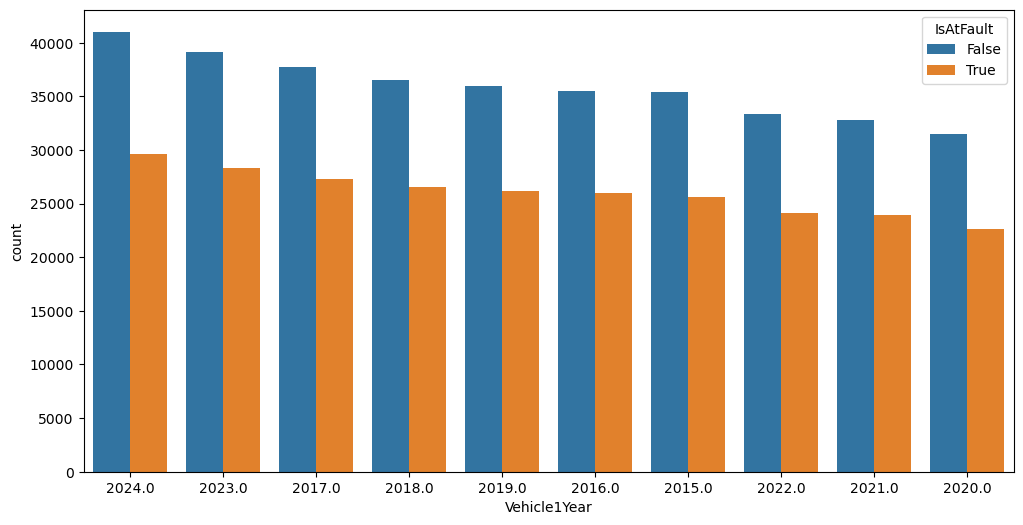

In [23]:
plt.figure(figsize=(12,6))
sns.countplot(data=crash_parties_car_background_data, x='Vehicle1Year', hue = 'IsAtFault', order=crash_parties_car_background_data['Vehicle1Year'].value_counts().iloc[:10].index)

<Axes: xlabel='Vehicle1Color', ylabel='count'>

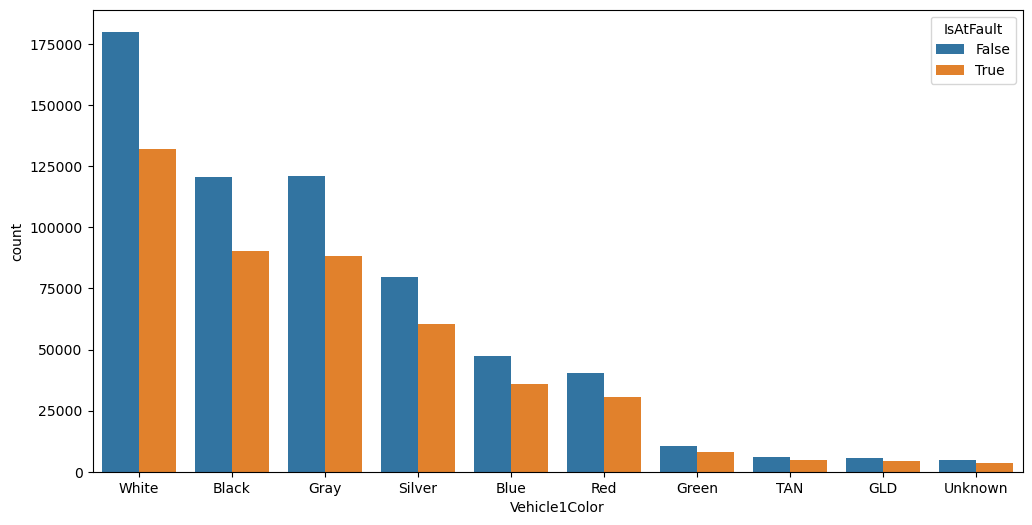

In [25]:
plt.figure(figsize=(12,6))
sns.countplot(data=crash_parties_car_background_data, x='Vehicle1Color', hue = 'IsAtFault', order=crash_parties_car_background_data['Vehicle1Color'].value_counts().iloc[:10].index)

In [26]:
crash_parties_speed_limit_data 
crash_roads_data

crash_roads_speed_limit_data = pd.merge(crash_roads_data, crash_parties_speed_limit_data, on='CollisionId', how='inner')

In [ ]:
crash_roads_speed_limit_data.head()

,Unnamed: 0_x,CollisionId,PrimaryRoad,IsFreeway,IsHighwayRelated,Unnamed: 0_y,SpeedLimit
0,0,4550265,SR-79 N/B,False,True,10782,55.0
1,0,4550265,SR-79 N/B,False,True,10783,55.0
2,1,4550264,N EL CAMINO REAL,False,False,10784,35.0
3,1,4550264,N EL CAMINO REAL,False,False,10785,35.0
4,2,4550263,SR-170 S/B FROM SHERMAN WAY,True,True,10786,65.0


In [28]:
highway_crash_roads = crash_roads_speed_limit_data[crash_roads_speed_limit_data['IsHighwayRelated'] == True]

<Axes: xlabel='PrimaryRoad', ylabel='count'>

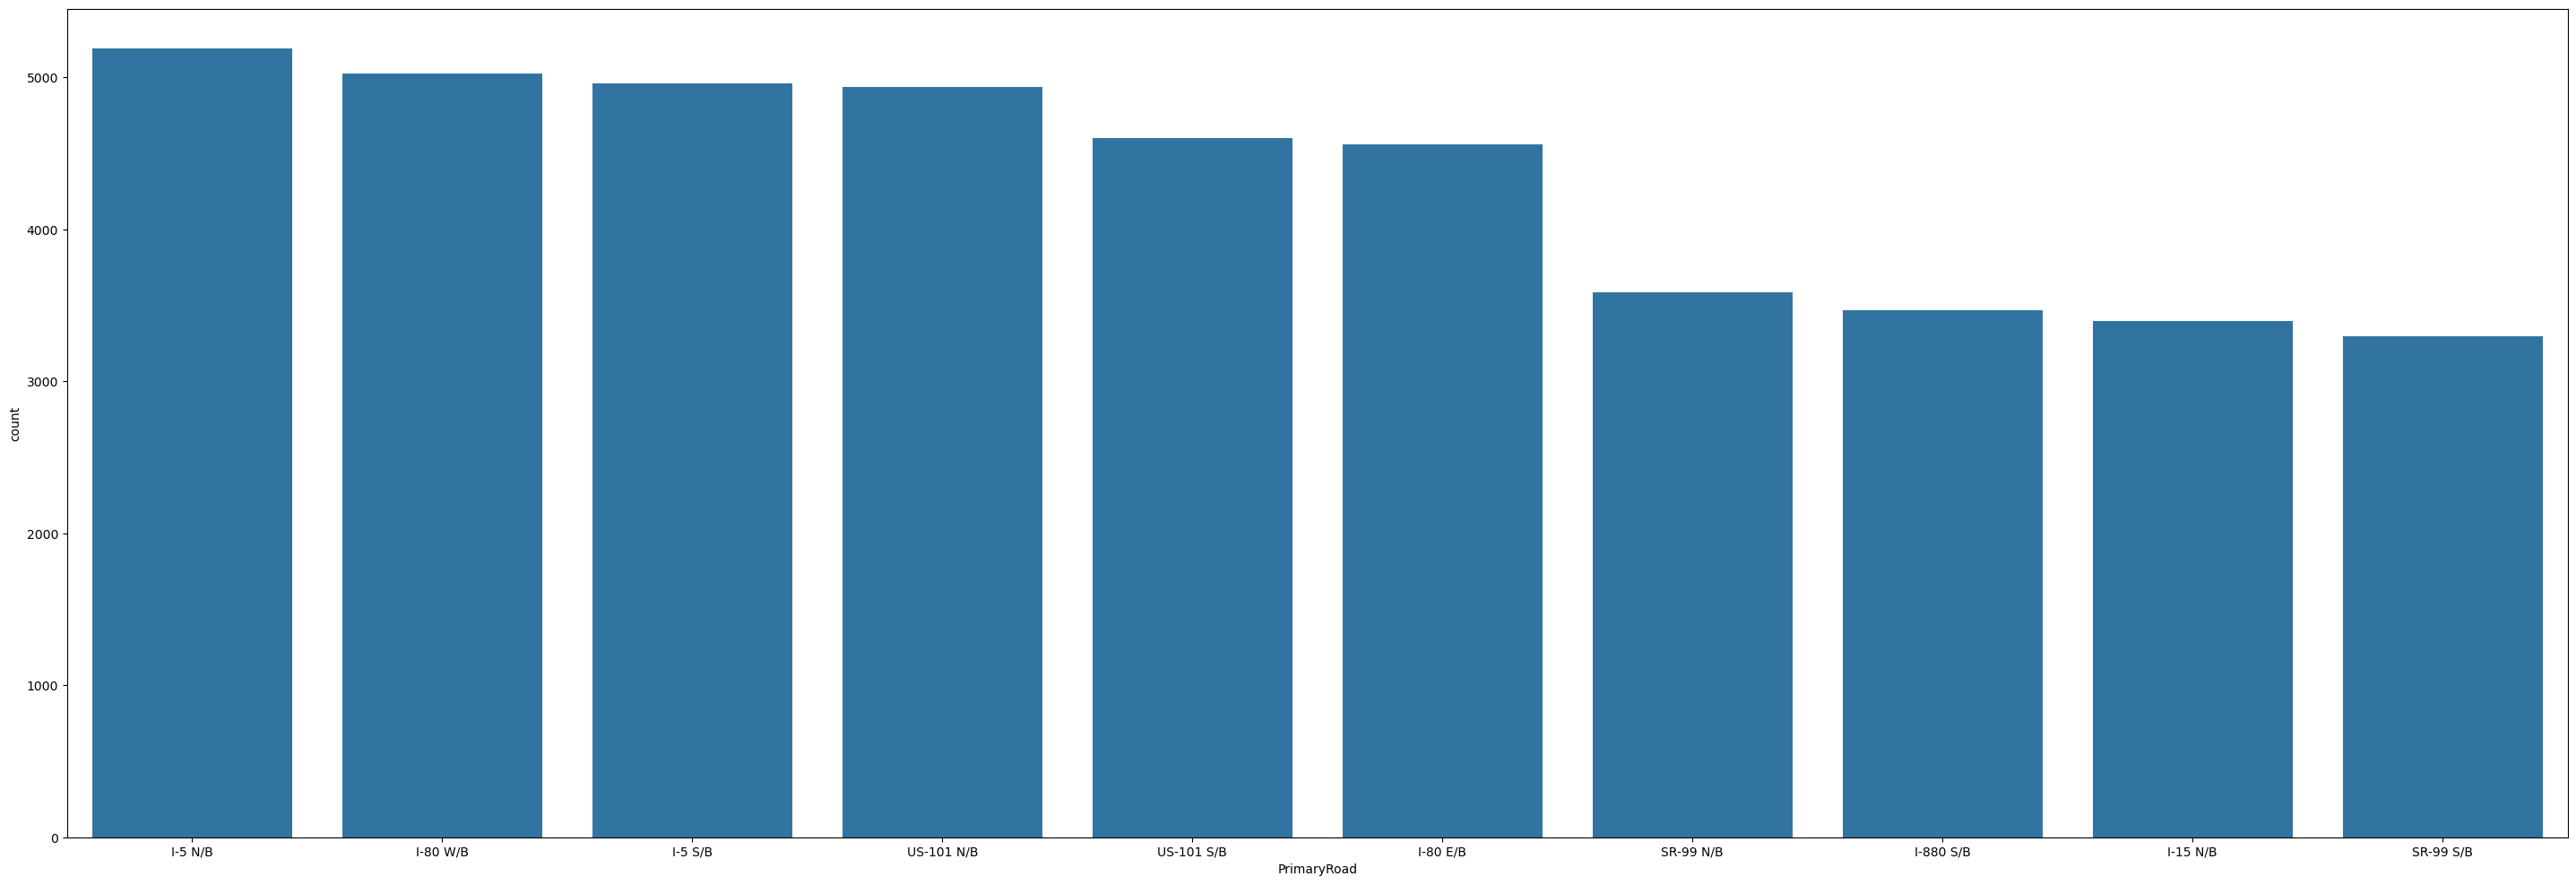

In [41]:
plt.figure(figsize=(36,12))
sns.countplot(data=highway_crash_roads, x='PrimaryRoad', order=highway_crash_roads['PrimaryRoad'].value_counts().iloc[:10].index)

In [43]:
highway_crash_roads['PrimaryRoad'] = highway_crash_roads['PrimaryRoad'].str.replace('N/B', '').str.replace('S/B', '').str.replace('E/B', '').str.replace('W/B', '') # Remove all directions

<Axes: xlabel='PrimaryRoad', ylabel='count'>

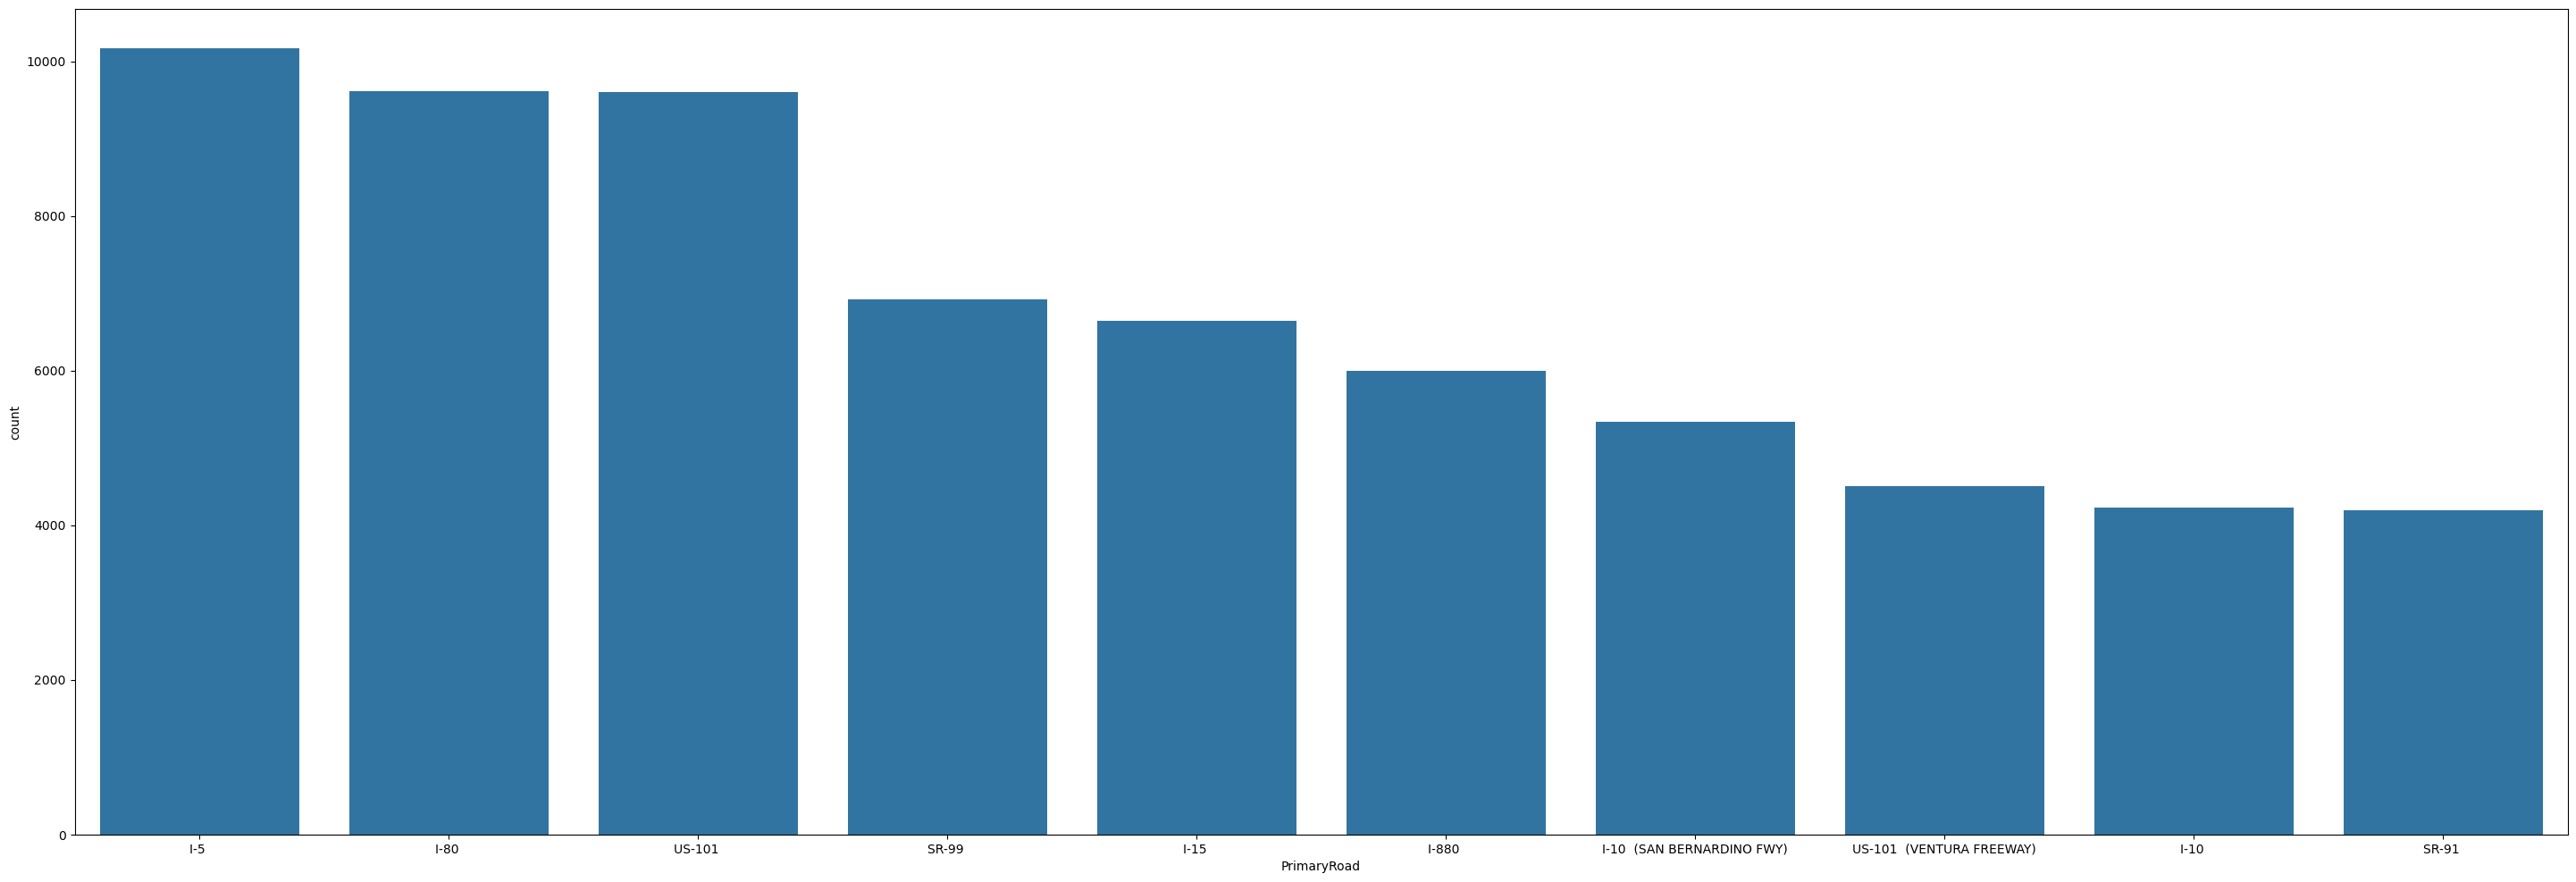

In [45]:
plt.figure(figsize=(36,12))
sns.countplot(data=highway_crash_roads, x='PrimaryRoad', order=highway_crash_roads['PrimaryRoad'].value_counts().iloc[:10].index)

In [63]:
crash_parties_car_data
crash_parties_background_data
crash_data_collision_factors

crash_parties_car_collision_background = pd.merge(crash_parties_car_background_data, crash_data_collision_factors, on='CollisionId', how='inner')
crash_parties_car_collision_background.head()

,Unnamed: 0_x,CollisionId,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,Unnamed: 0_y,PartyType,Special Information,IsAtFault,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,NumberKilled,Primary Collision Factor Code,Primary Collision Factor Violation,PrimaryCollisionFactorIsCited,PrimaryCollisionPartyNumber,parsed_values
0,1,4541901,2005.0,FORD,F-150,Gray,True,1,Driver,CELL PHONE NOT IN USE,False,True,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21453(a),True,1.0,21453.0
1,1,4541901,2005.0,FORD,F-150,Gray,True,2,Driver,CELL PHONE USE UNKNOWN,True,True,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21453(a),True,1.0,21453.0
2,2,4541901,2002.0,FORD,TAURUS,GLD,True,1,Driver,CELL PHONE NOT IN USE,False,True,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21453(a),True,1.0,21453.0
3,2,4541901,2002.0,FORD,TAURUS,GLD,True,2,Driver,CELL PHONE USE UNKNOWN,True,True,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21453(a),True,1.0,21453.0
4,5,4541899,2019.0,TOYOTA,4-RUNNER,Blue,False,5,Driver,CELL PHONE NOT IN USE,False,False,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21658(a),False,1.0,21658.0


<Axes: xlabel='Vehicle1Year', ylabel='NumberInjured'>

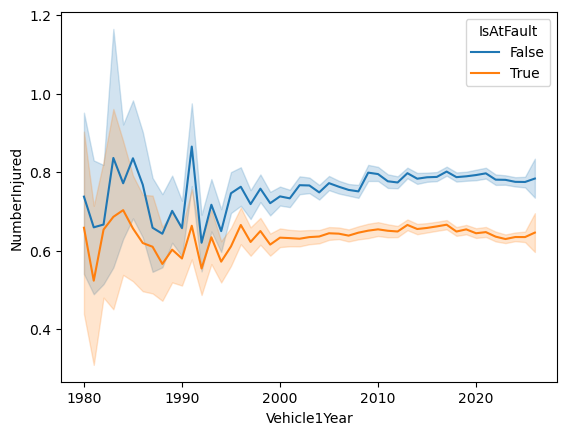

In [64]:
sns.lineplot(data=crash_parties_car_collision_background, x='Vehicle1Year', y='NumberInjured', hue='IsAtFault')

<Axes: xlabel='Vehicle1Year', ylabel='NumberKilled'>

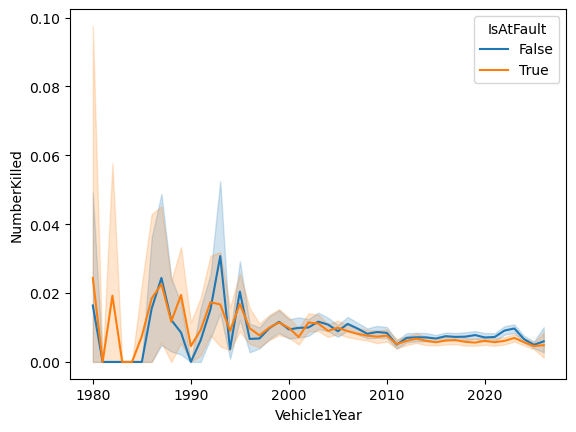

In [65]:
sns.lineplot(data=crash_parties_car_collision_background, x='Vehicle1Year', y='NumberKilled', hue='IsAtFault')

Note that when it says IsAtFault the point refers to the data point in that instance determing if the person in the accident was the one that caused the accident or not

<Axes: xlabel='V1IsVehicleTowed', ylabel='NumberInjured'>

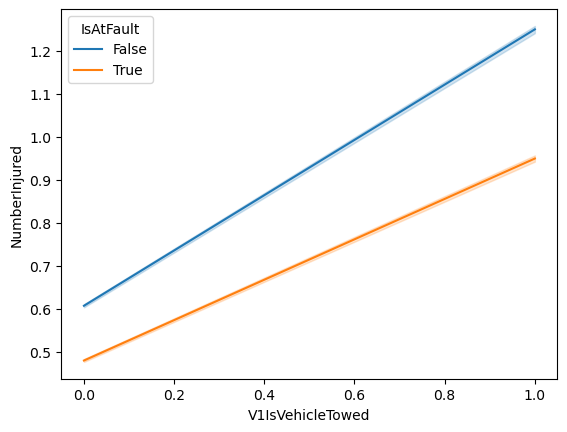

In [67]:
sns.lineplot(data=crash_parties_car_collision_background, x='V1IsVehicleTowed', y='NumberInjured', hue='IsAtFault')

<Axes: xlabel='IsTowAway', ylabel='NumberInjured'>

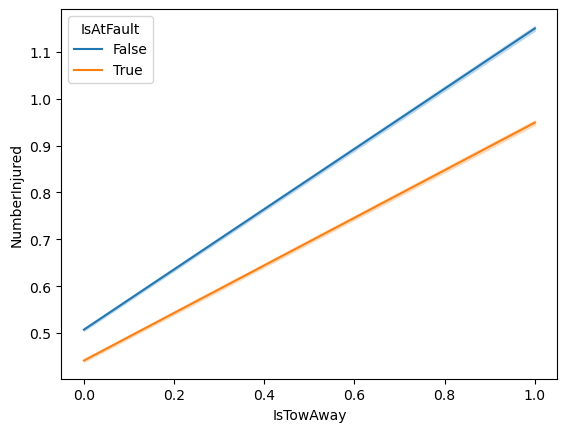

In [69]:
sns.lineplot(data=crash_parties_car_collision_background, x='IsTowAway', y='NumberInjured', hue='IsAtFault')

<Axes: xlabel='V1IsVehicleTowed', ylabel='NumberKilled'>

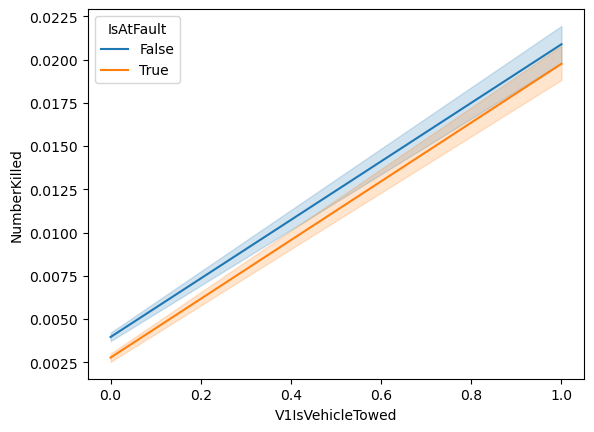

In [68]:
sns.lineplot(data=crash_parties_car_collision_background, x='V1IsVehicleTowed', y='NumberKilled', hue='IsAtFault')

<Axes: xlabel='IsTowAway', ylabel='NumberKilled'>

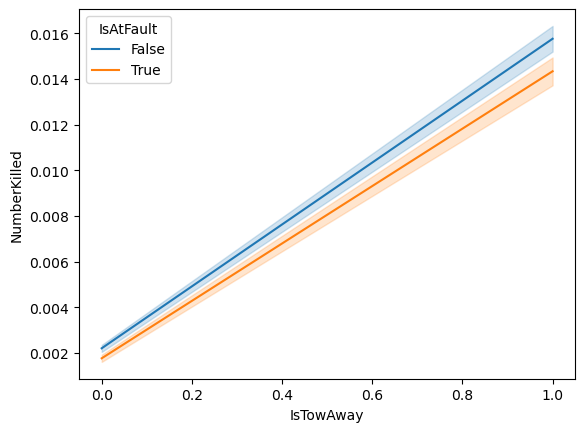

In [70]:
sns.lineplot(data=crash_parties_car_collision_background, x='IsTowAway', y='NumberKilled', hue='IsAtFault')

<Axes: xlabel='Vehicle1Model', ylabel='NumberInjured'>

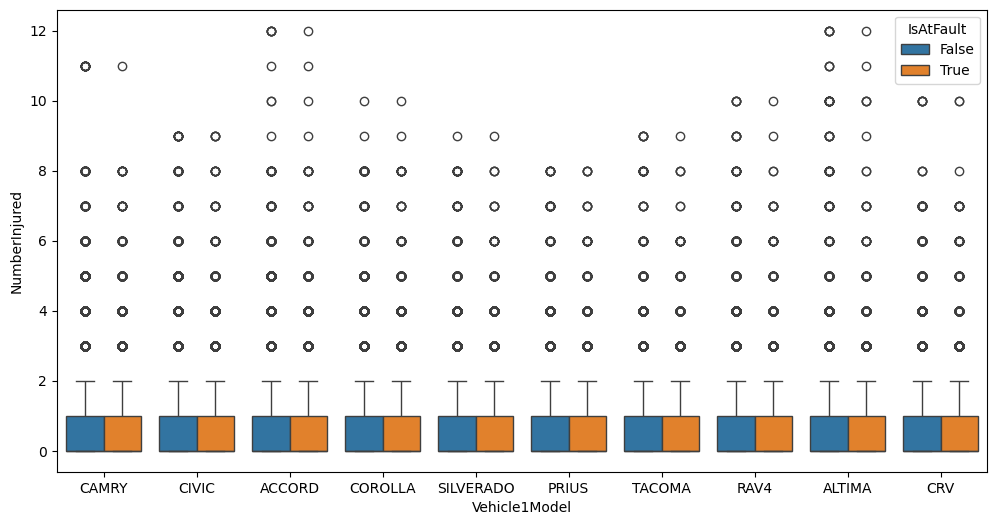

In [75]:
plt.figure(figsize=(12,6))
sns.boxplot(data=crash_parties_car_collision_background, x='Vehicle1Model', y ='NumberInjured', hue='IsAtFault', order=crash_parties_car_collision_background['Vehicle1Model'].value_counts().iloc[:10].index)

<Axes: xlabel='Vehicle1Model', ylabel='NumberKilled'>

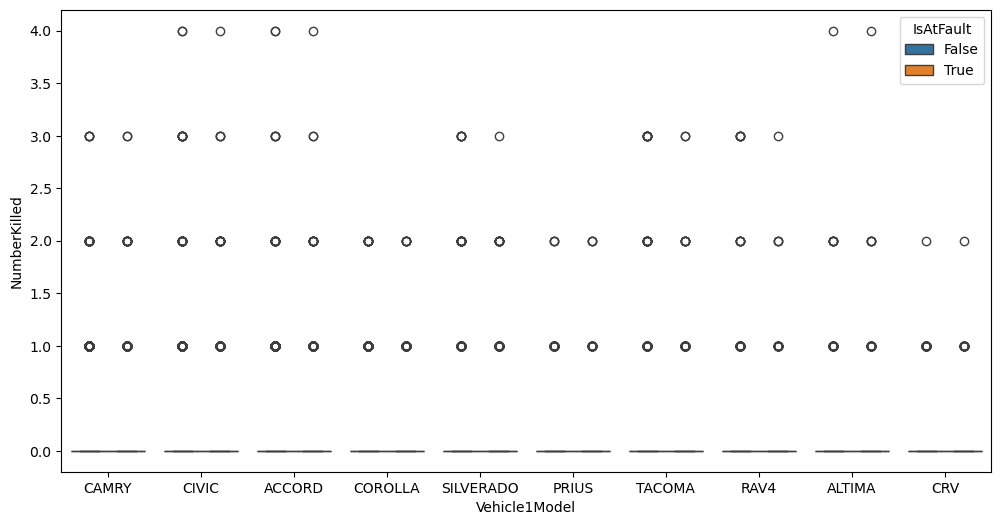

In [76]:
plt.figure(figsize=(12,6))
sns.boxplot(data=crash_parties_car_collision_background, x='Vehicle1Model', y ='NumberKilled', hue='IsAtFault', order=crash_parties_car_collision_background['Vehicle1Model'].value_counts().iloc[:10].index)

In [78]:
crash_parties_car_collision_background['PartyType'].value_counts()

PartyType
Driver           990599
ParkedVehicle     74868
Pedestrian         5742
Bicyclist          5137
Other              3461
Operator            305
Name: count, dtype: int64

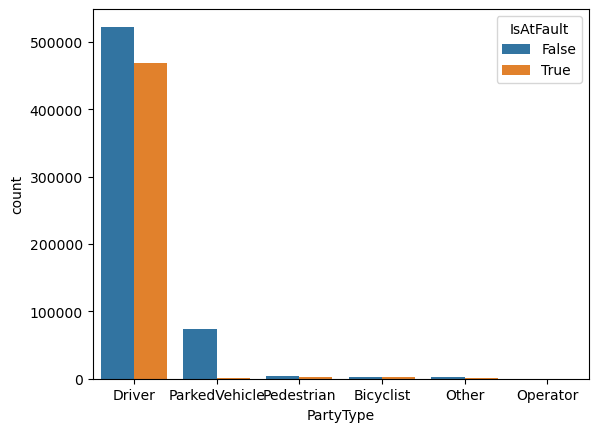

In [88]:
ax = sns.countplot(data=crash_parties_car_collision_background, x='PartyType', hue='IsAtFault')


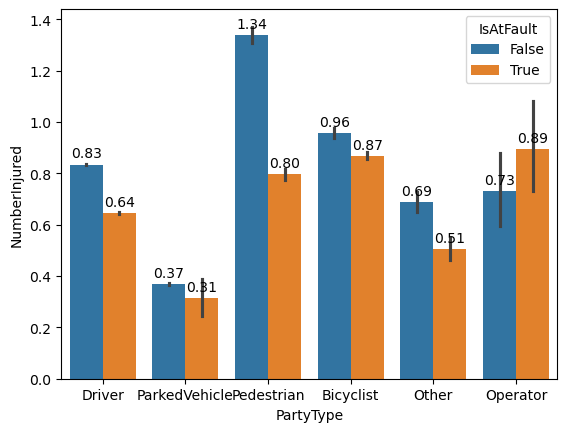

In [90]:
ax = sns.barplot(data=crash_parties_car_collision_background, x='PartyType', y='NumberInjured', hue='IsAtFault')
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

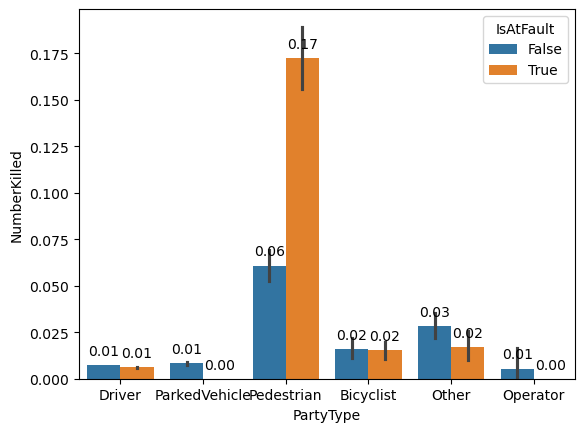

In [92]:
ax = sns.barplot(data=crash_parties_car_collision_background, x='PartyType', y='NumberKilled', hue='IsAtFault')
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=5)